# Differential Abundance Analysis

This notebook identifies bacterial taxa that differ significantly in abundance between the BF and EU samples, with the goal of characterizing the taxa driving compositional differences between the two populations. Differential abundance is evaluated at multiple taxonomic ranks using methods appropriate for sparse, compositional microbiome data, with multiple-testing correction applied across taxa.


Tutorial used: `https://www.bioconductor.org/packages/devel/bioc/vignettes/ANCOMBC/inst/doc/ANCOMBC.html`



ANCOM-BC2's sensitivity analysis assesses whether differential-abundance findings are robust to the choice of pseudocount added to zero observations.

taxon abundance ~ population

ANCOM-BC2 fits a log-linear regression model for each taxon, but with microbiome-specific bias correction wrapped around it.

### Import Libraries

In [2]:


suppressPackageStartupMessages({

########### main libraries ###########
library(SummarizedExperiment)
library(TreeSummarizedExperiment)
library(mia)
library(miaViz) # mia visualizatioon
# library(ALDEx2) # Main library for this diff abund
library(ANCOMBC) # Main library for this diff abund
    
########### data manipulation tools ###########
library(tidyverse)
library(tibble)
library(scales)

########### visualization libraries ###########   
library(ggrepel)
library(patchwork)
library(scater)

library(knitr)
library(ggplot2)
library(patchwork)
library(viridis)
    
########### resource management tools ###########
# library(tictoc)

################ notes ####################
### loaded by tidyverse
# library(ggplot2)
# library(tidyr)
# library(dplyr)
# library(readr)
# library(stringr)

})

warnLevel <- getOption('warn')
options(warn = -1)







### Arguments Piped in with R script Conversion

In [3]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [7]:
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ALPHA_DIV_DIR <-  file.path(ANALYSIS_DIR, "alpha_div")


In [8]:

tse <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse.withAlphaDiv.rds")))
# tse_genus <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_genus.withAlphaDiv.rds")))
# tse_phylum <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_phylum.withAlphaDiv.rds")))
metadata <- as.data.frame(colData(tse))



### Make Output Directory

In [9]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
DIFF_ABUND_DIR <-  file.path(ANALYSIS_DIR, "diff_abund")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_DIFF_ABUND_DIR <- file.path(FIG_DIR, "diff_abund")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(DIFF_ABUND_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIFF_ABUND_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [44]:
population_levels <- unique(colData(tse)$population_group)
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

# population_colors

## Analysis

In [10]:
# Confirm required data are present
assayNames(tse)
colnames(colData(tse))
colnames(rowData(tse))

[1] "counts"       "relabundance"

[1] "group"                            "run_id"                          
 [3] "population_group"                 "age_years"                       
 [5] "sex"                              "reported_ethnicity"              
 [7] "antibiotic_history"               "delivery_mode"                   
 [9] "clinical_status"                  "location"                        
[11] "coordinates"                      "diet_description"                
[13] "raw_reads"                        "trimmed_reads"                   
[15] "dada2_filtered_reads"             "dada2_denoised_reads"            
[17] "dada2_final_reads"                "primer_trim_retention_percent"   
[19] "dada2_final_retention_percent"    "total_pipeline_retention_percent"
[21] "raw_Q30_percent"                  "trimmed_Q30_percent"             
[23] "raw_mean_length"                  "trimmed_mean_length"             
[25] "final_read_depth"                 "observed_ASVs"                   
[27] "prevalent_abundance"              "observed"                        
[29] "chao1"                            "chao1_se"                        
[31] "shannon"                          "simpson"                         
[33] "gini_simpson"                     "inverse_simpson"                 
[35] "faith"

[1] "Kingdom"         "Phylum"          "Class"           "Order"          
[5] "Family"          "Genus"           "original_ASV_id" "prevalence"

In [11]:
# Raw counts must be present
assay(tse, "counts")[1:5, 1:5]

# Confirm groups
table(colData(tse)$population_group)

,10BF,10EU,11BF,11EU,12BF
ASV_1,5421,0,5943,0,12010
ASV_2,73,1036,0,5186,45
ASV_3,0,0,0,0,0
ASV_4,72,202,44,0,50
ASV_5,0,0,0,0,0



BF EU 
14 15 

In [12]:
colData(tse)$population_group <- factor(
    colData(tse)$population_group,
    levels = c("BF", "EU")
)

table(colData(tse)$population_group)


BF EU 
14 15 

BF = ref level

#### agglomerate

In [14]:
tse_phylum <- agglomerateByRank(
    tse,
    rank = "Phylum"
)



tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus"
)



In [16]:
# get rid of any ASVs without an associated phylum
keep_phylum <- (
    !is.na(rowData(tse_phylum)$Phylum) &
    rowData(tse_phylum)$Phylum != ""
)

tse_phylum <- tse_phylum[keep_phylum, ]



# get rid of any ASVs without an associated genus
keep_genus <- (
    !is.na(rowData(tse_genus)$Genus) &
    rowData(tse_genus)$Genus != ""
)

tse_genus <- tse_genus[keep_genus, ]





### Run ANCOMB

from the vignette : `https://bioconductor.org/packages//release/bioc/vignettes/ANCOMBC/inst/doc/ANCOMBC.html`

"Result from the ANCOM-BC log-linear model to determine taxa that are differentially abundant according to the covariate of interest. It contains: 1) log fold changes; 2) standard errors; 3) test statistics; 4) p-values; 5) adjusted p-values; 6) indicators whether the taxon is differentially abundant (TRUE) or not (FALSE)."

In [40]:
# help(ancombc)

In [21]:
set.seed(123)

ancom_phylum <- ancombc2(
    data = tse_phylum,
    assay_name = "counts",
    tax_level = NULL,

    fix_formula = "population_group",
    rand_formula = NULL,

    p_adj_method = "BH",
    prv_cut = 0.10, # prevalence 10% of samples
    lib_cut = 0,

    s0_perc = 0.05,
    group = "population_group", # default

    struc_zero = TRUE,
    neg_lb = FALSE,

    alpha = 0.05,

    global = FALSE,
    pairwise = FALSE,
    dunnet = FALSE,
    trend = FALSE,

    n_cl = 1,
    verbose = TRUE
)

Checking the input data type ...

The input data is of type: TreeSummarizedExperiment

PASS

Checking the sample metadata ...

The specified variables in the formula: population_group

The available variables in the sample metadata: group, run_id, population_group, age_years, sex, reported_ethnicity, antibiotic_history, delivery_mode, clinical_status, location, coordinates, diet_description, raw_reads, trimmed_reads, dada2_filtered_reads, dada2_denoised_reads, dada2_final_reads, primer_trim_retention_percent, dada2_final_retention_percent, total_pipeline_retention_percent, raw_Q30_percent, trimmed_Q30_percent, raw_mean_length, trimmed_mean_length, final_read_depth, observed_ASVs, prevalent_abundance, observed, chao1, chao1_se, shannon, simpson, gini_simpson, inverse_simpson, faith

PASS

Checking other arguments ...

The number of groups of interest is: 2

The sample size per group is: BF = 14, EU = 15

PASS

Obtaining initial estimates ...

Estimating sample-specific biases ...

ANCOM

In [22]:
ancom_genus <- ancombc2(
    data = tse_genus,
    assay_name = "counts",
    tax_level = NULL,

    fix_formula = "population_group",
    rand_formula = NULL,

    p_adj_method = "BH",
    prv_cut = 0.10, # prevalence 10% of samples
    lib_cut = 0,

    s0_perc = 0.05, # default
    group = "population_group",

    struc_zero = TRUE,
    neg_lb = FALSE,

    alpha = 0.05,

    global = FALSE,
    pairwise = FALSE,
    dunnet = FALSE,
    trend = FALSE,

    n_cl = 1,
    verbose = TRUE
)

Checking the input data type ...

The input data is of type: TreeSummarizedExperiment

PASS

Checking the sample metadata ...

The specified variables in the formula: population_group

The available variables in the sample metadata: group, run_id, population_group, age_years, sex, reported_ethnicity, antibiotic_history, delivery_mode, clinical_status, location, coordinates, diet_description, raw_reads, trimmed_reads, dada2_filtered_reads, dada2_denoised_reads, dada2_final_reads, primer_trim_retention_percent, dada2_final_retention_percent, total_pipeline_retention_percent, raw_Q30_percent, trimmed_Q30_percent, raw_mean_length, trimmed_mean_length, final_read_depth, observed_ASVs, prevalent_abundance, observed, chao1, chao1_se, shannon, simpson, gini_simpson, inverse_simpson, faith

PASS

Checking other arguments ...

The number of groups of interest is: 2

The sample size per group is: BF = 14, EU = 15

PASS

Obtaining initial estimates ...

Estimating sample-specific biases ...

ANCOM

In [28]:
# ancom_phylum

In [26]:
# ancom_genus

### Analyze Genus results

In [29]:
genus_results <- ancom_genus$res |>
    select(
        taxon,
        lfc_population_groupEU,
        se_population_groupEU,
        W_population_groupEU,
        p_population_groupEU,
        q_population_groupEU,
        diff_population_groupEU,
        passed_ss_population_groupEU,
        diff_robust_population_groupEU
    ) |>
    arrange(q_population_groupEU)

head(genus_results, 20)

,taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>
1,Segatella,-3.892100,0.3576074,-10.883724,6.678498e-08,4.207454e-06,TRUE,TRUE,TRUE
2,Parabacteroides,2.387756,0.3275450,7.289858,1.263415e-06,3.979759e-05,TRUE,FALSE,FALSE
3,Dorea,-1.966093,0.3305912,-5.947205,5.512449e-06,1.157614e-04,TRUE,TRUE,TRUE
4,Collinsella,-2.015515,0.3517656,-5.729711,3.102266e-05,4.886069e-04,TRUE,FALSE,FALSE
5,UCG-005,-1.462385,0.2941211,-4.972050,1.384629e-04,1.744633e-03,TRUE,FALSE,FALSE
6,Sutterella,1.398480,0.2661279,5.254917,2.705285e-04,1.893700e-03,TRUE,FALSE,FALSE
7,Alistipes,2.068168,0.4016559,5.149104,2.413426e-04,1.893700e-03,TRUE,TRUE,TRUE
8,Agathobaculum,-1.467471,0.2873025,-5.107757,2.584536e-04,1.893700e-03,TRUE,FALSE,FALSE
9,[Ruminococcus] gauvreauii group,-1.906190,0.2830469,-6.734539,2.687857e-04,1.893700e-03,TRUE,FALSE,FALSE


In [30]:
sum(genus_results$diff_population_groupEU)
sum(genus_results$diff_robust_population_groupEU)



genus_results |>
    filter(diff_robust_population_groupEU) |>
    arrange(lfc_population_groupEU)

[1] 25

[1] 3

taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>
Segatella,-3.892100,0.3576074,-10.883724,6.678498e-08,4.207454e-06,TRUE,TRUE,TRUE
Dorea,-1.966093,0.3305912,-5.947205,5.512449e-06,1.157614e-04,TRUE,TRUE,TRUE
Alistipes,2.068168,0.4016559,5.149104,2.413426e-04,1.893700e-03,TRUE,TRUE,TRUE


In [41]:
head(ancom_genus$zero_ind)

,taxon,structural_zero (population_group = BF),structural_zero (population_group = EU)
,<chr>,<lgl>,<lgl>
1,TM7x,TRUE,FALSE
2,Fusobacterium,TRUE,FALSE
3,Klebsiella,FALSE,FALSE
4,Kosakonia,TRUE,FALSE
5,Cedecea,TRUE,FALSE
6,Escherichia-Shigella,FALSE,FALSE


In [32]:
genus_robust <- genus_results |>
    filter(diff_robust_population_groupEU) |>
    mutate(
        enriched_in = if_else(
            lfc_population_groupEU > 0,
            "EU",
            "BF"
        )
    ) |>
    arrange(lfc_population_groupEU)

genus_robust

taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU,enriched_in
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>
Segatella,-3.892100,0.3576074,-10.883724,6.678498e-08,4.207454e-06,TRUE,TRUE,TRUE,BF
Dorea,-1.966093,0.3305912,-5.947205,5.512449e-06,1.157614e-04,TRUE,TRUE,TRUE,BF
Alistipes,2.068168,0.4016559,5.149104,2.413426e-04,1.893700e-03,TRUE,TRUE,TRUE,EU


In [34]:
genus_structural_zeros <- ancom_genus$zero_ind |>
    filter(
        `structural_zero (population_group = BF)` |
        `structural_zero (population_group = EU)`
    ) |>
    mutate(
        enriched_in = case_when(
            `structural_zero (population_group = BF)` ~ "EU",
            `structural_zero (population_group = EU)` ~ "BF"
        )
    )



BF EU 
43 53 

In [42]:
# Robust genus-level results
genus_robust <- genus_results |>
    filter(diff_robust_population_groupEU) |>
    mutate(
        enriched_in = if_else(
            lfc_population_groupEU < 0,
            "BF",
            "EU"
        )
    )

genus_robust

taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU,enriched_in
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>
Segatella,-3.892100,0.3576074,-10.883724,6.678498e-08,4.207454e-06,TRUE,TRUE,TRUE,BF
Dorea,-1.966093,0.3305912,-5.947205,5.512449e-06,1.157614e-04,TRUE,TRUE,TRUE,BF
Alistipes,2.068168,0.4016559,5.149104,2.413426e-04,1.893700e-03,TRUE,TRUE,TRUE,EU


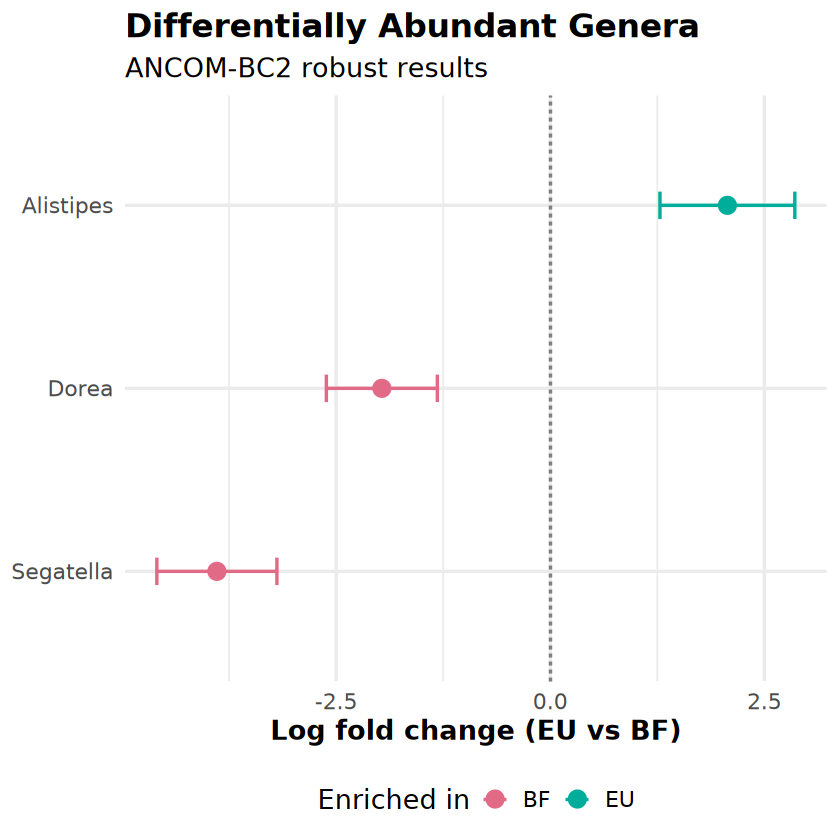

In [45]:
p_da_genus <- genus_robust |>
    mutate(
        taxon = reorder(taxon, lfc_population_groupEU)
    ) |>
    ggplot(
        aes(
            x = lfc_population_groupEU,
            y = taxon,
            color = enriched_in
        )
    ) +
    geom_vline(
        xintercept = 0,
        linetype = "dashed",
        color = "grey50"
    ) +
    geom_errorbar(
        aes(
            xmin = lfc_population_groupEU - 1.96 * se_population_groupEU,
            xmax = lfc_population_groupEU + 1.96 * se_population_groupEU
        ),
        width = 0.15
    ) +
    geom_point(size = 4) +
    scale_color_manual(values = population_colors) +
    labs(
        title = "Differentially Abundant Genera",
        subtitle = "ANCOM-BC2 robust results",
        x = "Log fold change (EU vs BF)",
        y = NULL,
        color = "Enriched in"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(face = "bold"),
        axis.title.x = element_text(face = "bold"),
        legend.position = "bottom"
    )

p_da_genus

In [61]:


# save figure 
ggsave(
    filename = paste0(FIG_DIFF_ABUND_DIR, '/', PROJECT_NAME, '.diffAbund.robustGenera.png'),
    plot = p_da_genus,
    width = 8,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_DIFF_ABUND_DIR, '/', PROJECT_NAME, '.diffAbund.robustGenera.pdf'),
    plot = p_da_genus,
    width = 8,
    height = 8,
    units = "in",
    bg = "white"
)






write_tsv( 
    genus_results,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".diffAbund.genus.tsv")),
    quote = "needed"
)


write_tsv( 
    genus_structural_zeros,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".diffAbund.genus.StructuralZeros.tsv")),
    quote = "needed"
)







### Get genera that are abundant but exclusive to one group

In [55]:
# extract abundances table
relabund_genus <- assay(tse_genus, "relabundance")

groups <- colData(tse_genus)$population_group

# Calculate mean relative abundance within each population
genus_mean_abundance <- data.frame(
    taxon = rownames(relabund_genus),
    mean_abundance_BF = rowMeans(
        relabund_genus[, groups == "BF", drop = FALSE]
    ),
    mean_abundance_EU = rowMeans(
        relabund_genus[, groups == "EU", drop = FALSE]
    )
)

# add abundance information to structural-zero table
genus_structural_zeros_abundant <- genus_structural_zeros |>
    left_join(
        genus_mean_abundance,
        by = "taxon"
    ) |>
    mutate(
        mean_abundance = if_else(
            enriched_in == "BF",
            mean_abundance_BF,
            mean_abundance_EU
        )
    ) |>
    # Keep taxa averaging >= 1% in the group where present
    filter(mean_abundance >= 0.01) |>
    arrange(desc(mean_abundance))

genus_structural_zeros_abundant

taxon,structural_zero (population_group = BF),structural_zero (population_group = EU),enriched_in,mean_abundance_BF,mean_abundance_EU,mean_abundance
<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>
Bacteroides,TRUE,FALSE,EU,0.00000000,0.15367950,0.15367950
Leyella,FALSE,TRUE,BF,0.07521124,0.00000000,0.07521124
Succinivibrio,FALSE,TRUE,BF,0.01201572,0.00000000,0.01201572
Barnesiella,TRUE,FALSE,EU,0.00000000,0.01196025,0.01196025


In [59]:
abund_structural_zeros <- genus_structural_zeros_abundant |>
    transmute(
        Genus = taxon,
        `Associated group` = enriched_in,
        `Mean relative abundance (%)` = mean_abundance * 100
    )

abund_structural_zeros

Genus,Associated group,Mean relative abundance (%)
<chr>,<chr>,<dbl>
Bacteroides,EU,15.367950
Leyella,BF,7.521124
Succinivibrio,BF,1.201572
Barnesiella,EU,1.196025


In [60]:



write_tsv( 
    prominent_structural_zeros,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".diffAbund.genus.abund_and_zero.tsv")),
    quote = "needed"
)


### Analyze Phylum results

In [49]:
phylum_results <- ancom_phylum$res |>
    select(
        taxon,
        lfc_population_groupEU,
        se_population_groupEU,
        W_population_groupEU,
        p_population_groupEU,
        q_population_groupEU,
        diff_population_groupEU,
        passed_ss_population_groupEU,
        diff_robust_population_groupEU
    ) |>
    arrange(q_population_groupEU)

phylum_results

taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>
Bacteroidota,-1.67016105,0.4068719,-4.10488174,0.0003782949,0.002648064,TRUE,FALSE,FALSE
Campylobacterota,-2.16495117,0.2846536,-7.60556438,0.0016038346,0.005613421,TRUE,FALSE,FALSE
Patescibacteria,-6.21310458,0.2727563,-22.77895775,0.0279297798,0.065169486,FALSE,TRUE,FALSE
Pseudomonadota,-0.31422282,0.4884278,-0.64333531,0.5254334293,0.803690213,FALSE,FALSE,FALSE
Actinomycetota,0.39857015,0.6994096,0.56986653,0.5740644376,0.803690213,FALSE,FALSE,FALSE
Thermodesulfobacteriota,0.11404029,0.3064730,0.37210557,0.7175784260,0.837174830,FALSE,FALSE,FALSE
Bacillota,-0.03030719,0.3802437,-0.07970466,0.9370599896,0.937059990,FALSE,FALSE,FALSE


In [58]:

write_tsv( 
    phylum_results,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".diffAbund.phylum.tsv")),
    quote = "needed"
)



In [50]:
sum(phylum_results$diff_population_groupEU)
sum(phylum_results$diff_robust_population_groupEU)



phylum_results |>
    filter(diff_robust_population_groupEU) |>
    arrange(lfc_population_groupEU)

[1] 2

[1] 0

taxon,lfc_population_groupEU,se_population_groupEU,W_population_groupEU,p_population_groupEU,q_population_groupEU,diff_population_groupEU,passed_ss_population_groupEU,diff_robust_population_groupEU
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>


In [51]:
phylum_structural_zeros <- ancom_phylum$zero_ind |>
    filter(
        `structural_zero (population_group = BF)` |
        `structural_zero (population_group = EU)`
    ) |>
    mutate(
        enriched_in = case_when(
            `structural_zero (population_group = BF)` ~ "EU",
            `structural_zero (population_group = EU)` ~ "BF"
        )
    )


In [52]:
phylum_structural_zeros

taxon,structural_zero (population_group = BF),structural_zero (population_group = EU),enriched_in
<chr>,<lgl>,<lgl>,<chr>
Fusobacteriota,TRUE,FALSE,EU
Spirochaetota,FALSE,TRUE,BF
Verrucomicrobiota,TRUE,FALSE,EU


In [57]:
# extract abundances table
relabund_phylum <- assay(tse_phylum, "relabundance")

groups <- colData(tse_phylum)$population_group

# Calculate mean relative abundance within each population
phylum_mean_abundance <- data.frame(
    taxon = rownames(relabund_phylum),
    mean_abundance_BF = rowMeans(
        relabund_phylum[, groups == "BF", drop = FALSE]
    ),
    mean_abundance_EU = rowMeans(
        relabund_phylum[, groups == "EU", drop = FALSE]
    )
)

# add abundance information to structural-zero table
phylum_structural_zeros_abundant <- phylum_structural_zeros |>
    left_join(
        phylum_mean_abundance,
        by = "taxon"
    ) |>
    mutate(
        mean_abundance = if_else(
            enriched_in == "BF",
            mean_abundance_BF,
            mean_abundance_EU
        )
    ) |>
    # Keep taxa averaging >= 1% in the group where present
    filter(mean_abundance >= 0.01) |>
    arrange(desc(mean_abundance))

phylum_structural_zeros_abundant

taxon,structural_zero (population_group = BF),structural_zero (population_group = EU),enriched_in,mean_abundance_BF,mean_abundance_EU,mean_abundance
<chr>,<lgl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>
